# Análise Exploratória de Dados (EDA – Exploratory Data Analysis).

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [60]:
df = pd.read_csv('../data/global_supply_chain_risk_2026.csv')

In [61]:
print(f'O Dataset contém {df.shape[0]} linhas e {df.shape[1]} colunas.')

O Dataset contém 5000 linhas e 14 colunas.


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   str    
 1   Date                       5000 non-null   str    
 2   Origin_Port                5000 non-null   str    
 3   Destination_Port           5000 non-null   str    
 4   Transport_Mode             5000 non-null   str    
 5   Product_Category           5000 non-null   str    
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   str    
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64  
dtypes: 

In [63]:
(df.describe().T).round(2)

,count,mean,std,min,25%,50%,75%,max
Distance_km,5000.0,7704.06,4199.69,500.17,4036.01,7750.12,11347.46,14995.91
Weight_MT,5000.0,246.25,142.52,1.03,124.33,243.50,366.96,499.75
Fuel_Price_Index,5000.0,2.85,0.96,1.20,2.02,2.84,3.71,4.50
Geopolitical_Risk_Score,5000.0,5.08,2.88,0.00,2.60,5.10,7.50,10.00
Carrier_Reliability_Score,5000.0,0.75,0.14,0.50,0.63,0.76,0.88,1.00
Lead_Time_Days,5000.0,19.36,31.41,0.50,2.11,8.25,21.21,236.39
Disruption_Occurred,5000.0,0.61,0.49,0.00,0.00,1.00,1.00,1.00


In [64]:
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [65]:
df.tail()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
4995,SC-14995,2025-11-10,Rotterdam,Dubai,Rail,Perishables,13512.26,428.97,3.35,8.8,Fog,0.664,20.28,0
4996,SC-14996,2025-11-23,Dubai,Shanghai,Air,Perishables,2231.02,448.86,1.79,0.5,Clear,0.863,0.50,0
4997,SC-14997,2025-10-18,Antwerp,Busan,Rail,Pharmaceuticals,5253.72,473.41,1.37,3.0,Clear,0.962,4.41,0
4998,SC-14998,2025-01-29,Singapore,Dubai,Rail,Automotive,12328.31,199.35,3.45,4.4,Storm,0.819,31.18,1
4999,SC-14999,2024-06-01,Dubai,Shanghai,Air,Textiles,9161.03,109.35,2.03,1.7,Storm,0.976,1.43,1


In [66]:
df.columns = ['id', 'data', 'porto_origem', 'porto_destino',
       'modo_transporte', 'categoria_produto', 'distancia_km', 'peso',
       'indice_preco_combustivel', 'nivel_risco', 'condicoes_temporais',
       'confiabilidade_transportadora', 'prazo_dias', 'houve_interrupcao']

In [67]:
df['data'] = pd.to_datetime(df['data'])

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   id                             5000 non-null   str           
 1   data                           5000 non-null   datetime64[us]
 2   porto_origem                   5000 non-null   str           
 3   porto_destino                  5000 non-null   str           
 4   modo_transporte                5000 non-null   str           
 5   categoria_produto              5000 non-null   str           
 6   distancia_km                   5000 non-null   float64       
 7   peso                           5000 non-null   float64       
 8   indice_preco_combustivel       5000 non-null   float64       
 9   nivel_risco                    5000 non-null   float64       
 10  condicoes_temporais            5000 non-null   str           
 11  confiabilidade_transportador

In [69]:
print(f'Maior data do Dataset é: {df['data'].max()}, e a menor data é: {df['data'].min()}, ou seja, o Dataset percorre 2 anos exatos.')

Maior data do Dataset é: 2025-12-31 00:00:00, e a menor data é: 2024-01-01 00:00:00, ou seja, o Dataset percorre 2 anos exatos.


# Desenvolvimento dos Insights

In [70]:
df.head()

,id,data,porto_origem,porto_destino,modo_transporte,categoria_produto,distancia_km,peso,indice_preco_combustivel,nivel_risco,condicoes_temporais,confiabilidade_transportadora,prazo_dias,houve_interrupcao
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


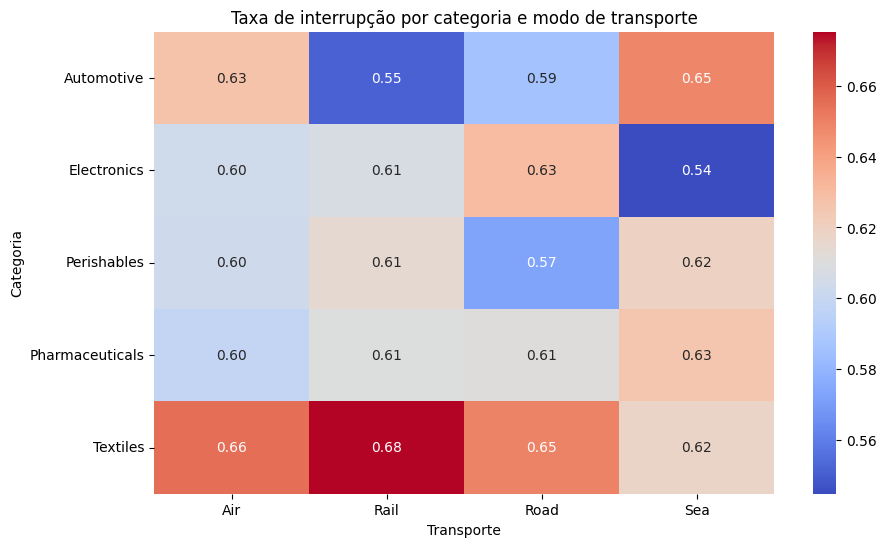

In [71]:
df_heat = df.pivot_table(
    index='categoria_produto',
    columns='modo_transporte',
    values='houve_interrupcao',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    df_heat,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.xlabel('Transporte')
plt.ylabel('Categoria')
plt.title('Taxa de interrupção por categoria e modo de transporte')
plt.show()

A análise da taxa de interrupção por categoria de produto e modo de transporte indica que Textiles transportado por Rail apresenta a maior taxa de interrupção (0.68), sugerindo que essa combinação é a mais vulnerável da cadeia logística e demanda maior atenção operacional.

Por outro lado, algumas combinações apresentam maior estabilidade, como Electronics transportado por Sea (0.54) e Automotive por Rail (0.55), que registraram menores taxas de interrupção, indicando operações logísticas relativamente mais confiáveis.

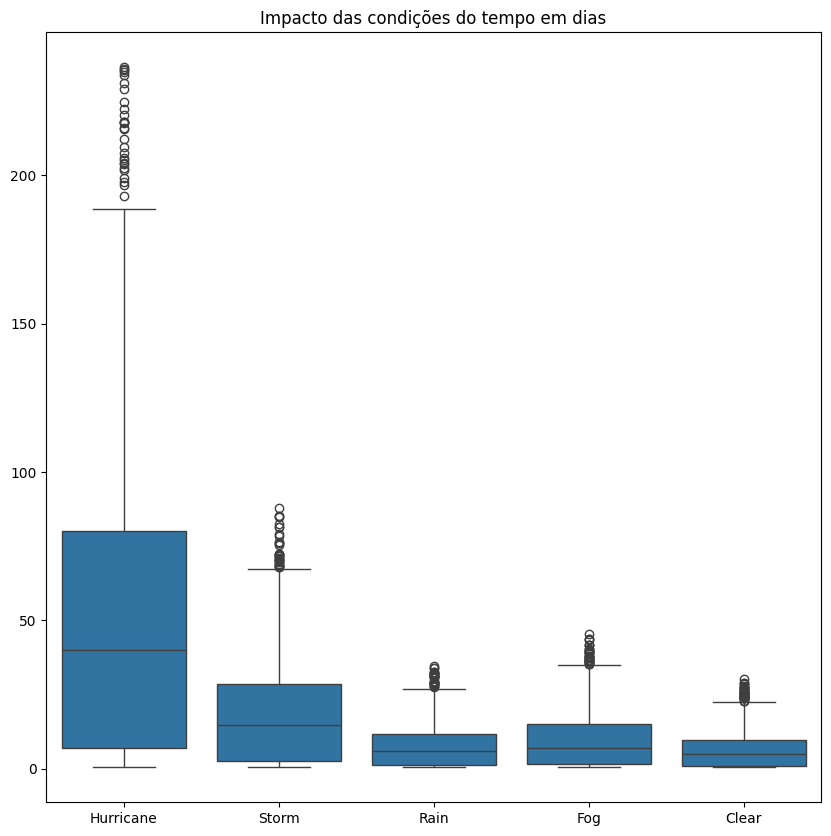

In [72]:

plt.figure(figsize=[10,10])
sns.boxplot(data=df, x='condicoes_temporais', y='prazo_dias')
plt.xlabel('')
plt.ylabel('')
plt.title('Impacto das condições do tempo em dias')
plt.show()

O boxplot mostra a distribuição do dos prazos em dias para diferentes condições climáticas. Observa-se que **furacões (Hurricane)** apresentam o maior impacto no tempo de entrega, com maior mediana e grande variabilidade, além de diversos outliers indicando atrasos extremos.

Tempestades (Storm) também aumentam o prazo, porém em menor magnitude. Já condições como **Rain, Fog e Clear** apresentam valores medianos mais baixos e menor dispersão.

Esses resultados indicam que **eventos climáticos extremos, especialmente furacões, são os principais responsáveis por grandes atrasos na cadeia de suprimentos**.

In [73]:
df.head()

,id,data,porto_origem,porto_destino,modo_transporte,categoria_produto,distancia_km,peso,indice_preco_combustivel,nivel_risco,condicoes_temporais,confiabilidade_transportadora,prazo_dias,houve_interrupcao
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [74]:
df_rotas = df.groupby(['porto_origem', 'porto_destino'])['prazo_dias'].mean().sort_values(ascending=False)

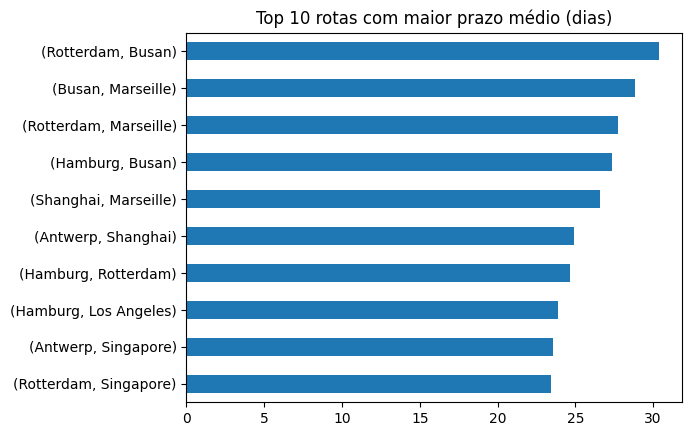

In [75]:
df_rotas.head(10).sort_values().plot(kind='barh', xlabel='',ylabel='', title='Top 10 rotas com maior prazo médio (dias)')
plt.show()

Observa-se que muitas das rotas com maior prazo médio envolvem conexões entre portos europeus (Rotterdam, Hamburg, Antwerp) e asiáticos (Busan, Shanghai, Singapore). 

Isso sugere que rotas intercontinentais tendem a apresentar maiores prazos médios, possivelmente devido a maiores distâncias marítimas, maior complexidade logística e maior probabilidade de atrasos portuários.

In [76]:
df_portos = df.groupby('porto_origem')['prazo_dias'].mean().sort_values(ascending=False)

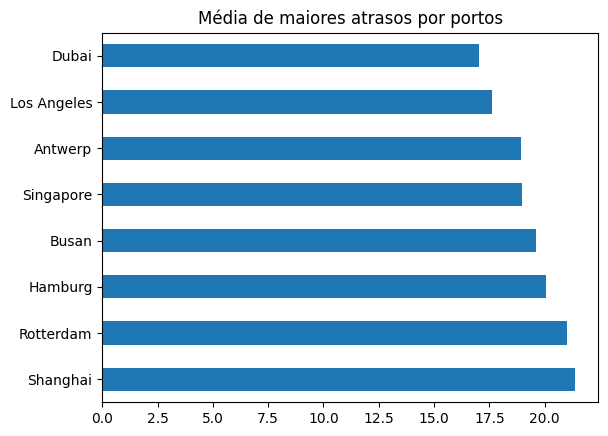

In [77]:
df_portos.plot(kind='barh', xlabel='',ylabel='', title='Média de maiores atrasos por portos')
plt.show()

A análise dos prazos médios por porto mostra que alguns portos estão associados a prazos de entrega mais elevados. Portos como **Shanghai, Rotterdam e Hamburg** apresentam os maiores tempos médios, o que pode indicar rotas mais longas, maior volume de carga ou maior complexidade logística nessas regiões.

Por outro lado, portos como **Dubai e Los Angeles** apresentam prazos médios menores em comparação com os demais, sugerindo operações logísticas potencialmente mais eficientes ou rotas mais curtas.

De forma geral, os resultados indicam que o desempenho logístico pode variar significativamente entre portos, possivelmente devido a fatores como distância das rotas, congestionamento portuário e infraestrutura logística.